# Week 3: Model Evaluation & Visualization

## Objective

The objective of this notebook is to evaluate the performance of forecasting models using chronological train-test splitting. The baseline forecasting model (Simple Moving Average) and the advanced forecasting model (ARIMA) are compared using RMSE and MAPE metrics. The notebook also visualizes actual vs. predicted values and summarizes the evaluation results.

## Member 2 Tasks

- Split the dataset into training and testing sets chronologically.
- Generate forecasts on the test dataset.
- Evaluate model performance using RMSE.
- Evaluate model performance using MAPE.
- Compare baseline and advanced forecasting models.
- Visualize actual vs. predicted values.
- Document evaluation results and performance observations.

In [1]:
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_percentage_error
)

print("Libraries Imported Successfully")

Libraries Imported Successfully


## Load Forecasting Datasets

Load the baseline forecasting dataset generated using the Simple Moving Average (SMA) model and the advanced forecasting dataset generated using the ARIMA model. These datasets will be used for model evaluation and performance comparison.

In [2]:
# Load Baseline Forecast Dataset

baseline_df = pd.read_excel("baseline_forecastingdataset.xlsx")

# Load Advanced Forecast Dataset

advanced_df = pd.read_excel("advanced_forecast.xlsx")

print("Datasets Loaded Successfully")

Datasets Loaded Successfully


## Verify Dataset Information

Display the first few records, dataset dimensions, column names, data types, and missing values to ensure that both datasets are ready for evaluation.

In [3]:
# Baseline Forecast Dataset Information

print("===== Baseline Forecast Dataset =====")

display(baseline_df.head())

print("\nShape:", baseline_df.shape)

print("\nColumns:")
print(baseline_df.columns)

print("\nData Types:")
print(baseline_df.dtypes)

print("\nMissing Values:")
print(baseline_df.isnull().sum())

===== Baseline Forecast Dataset =====


,Date,Units Sold,SMA_7
0,2022-01-01,14484,NaN
1,2022-01-02,13415,NaN
2,2022-01-03,13681,NaN
3,2022-01-04,14084,NaN
4,2022-01-05,12572,NaN



Shape: (731, 3)

Columns:
Index(['Date', 'Units Sold', 'SMA_7'], dtype='object')

Data Types:
Date          datetime64[ns]
Units Sold             int64
SMA_7                float64
dtype: object

Missing Values:
Date          0
Units Sold    0
SMA_7         6
dtype: int64


In [4]:
# Advanced Forecast Dataset Information

print("===== Advanced Forecast Dataset =====")

display(advanced_df.head())

print("\nShape:", advanced_df.shape)

print("\nColumns:")
print(advanced_df.columns)

print("\nData Types:")
print(advanced_df.dtypes)

print("\nMissing Values:")
print(advanced_df.isnull().sum())

===== Advanced Forecast Dataset =====


,Date,Actual,ARIMA_Prediction
0,2023-08-08,13666,14027.540056
1,2023-08-09,13956,13980.834023
2,2023-08-10,13028,13935.428368
3,2023-08-11,12414,13858.973033
4,2023-08-12,12124,14050.145085



Shape: (147, 3)

Columns:
Index(['Date', 'Actual', 'ARIMA_Prediction'], dtype='object')

Data Types:
Date                datetime64[ns]
Actual                       int64
ARIMA_Prediction           float64
dtype: object

Missing Values:
Date                0
Actual              0
ARIMA_Prediction    0
dtype: int64


## Chronological Train-Test Split

To evaluate the forecasting model fairly, the dataset is divided into training and testing sets while preserving the chronological order of observations. This approach ensures that future observations are not used during model training, making the evaluation realistic for time-series forecasting.

In [5]:
# Convert Date columns to datetime

advanced_df["Date"] = pd.to_datetime(advanced_df["Date"])
baseline_df["Date"] = pd.to_datetime(baseline_df["Date"])

# Sort both datasets

advanced_df = advanced_df.sort_values("Date").reset_index(drop=True)
baseline_df = baseline_df.sort_values("Date").reset_index(drop=True)

# Chronological Train-Test Split

split_index = int(len(advanced_df) * 0.80)

train_df = advanced_df.iloc[:split_index]
test_df = advanced_df.iloc[split_index:]

baseline_test = baseline_df.iloc[split_index:].reset_index(drop=True)

print("Training Dataset Shape :", train_df.shape)
print("Testing Dataset Shape  :", test_df.shape)

Training Dataset Shape : (117, 3)
Testing Dataset Shape  : (30, 3)


## Display Training and Testing Datasets

The first few records of both training and testing datasets are displayed to verify that the chronological split has been performed correctly.

In [6]:
print("Training Dataset")
display(train_df.head())

print("\nTesting Dataset")
display(test_df.head())

Training Dataset


,Date,Actual,ARIMA_Prediction
0,2023-08-08,13666,14027.540056
1,2023-08-09,13956,13980.834023
2,2023-08-10,13028,13935.428368
3,2023-08-11,12414,13858.973033
4,2023-08-12,12124,14050.145085



Testing Dataset


,Date,Actual,ARIMA_Prediction
117,2023-12-03,13116,13979.173587
118,2023-12-04,15286,13979.173587
119,2023-12-05,13829,13979.173587
120,2023-12-06,14194,13979.173587
121,2023-12-07,11947,13979.173587


## Generate Forecasts on the Test Dataset

The advanced forecasting model (ARIMA) has already been trained. In this step, the forecasted values corresponding to the testing dataset are extracted and prepared for model evaluation.

In [7]:
# Extract Actual and Predicted values from Testing Dataset

test_actual = test_df["Actual"]
test_predicted = test_df["ARIMA_Prediction"]

# Create Forecast Results DataFrame

forecast_results = pd.DataFrame({
    "Date": test_df["Date"],
    "Actual": test_actual,
    "Predicted": test_predicted
})

print("Forecasts Generated Successfully")

display(forecast_results.head())

Forecasts Generated Successfully


,Date,Actual,Predicted
117,2023-12-03,13116,13979.173587
118,2023-12-04,15286,13979.173587
119,2023-12-05,13829,13979.173587
120,2023-12-06,14194,13979.173587
121,2023-12-07,11947,13979.173587


## Forecast Summary

The testing dataset now contains the actual demand values along with the corresponding forecasted values generated by the trained ARIMA model. These values will be used to evaluate forecasting accuracy in the next steps using RMSE and MAPE.

## Evaluate Model Performance using RMSE

Root Mean Squared Error (RMSE) is used to measure the average magnitude of prediction errors. A lower RMSE value indicates better forecasting accuracy and a closer match between actual and predicted values.

In [8]:
# Calculate RMSE

rmse = np.sqrt(
    mean_squared_error(
        forecast_results["Actual"],
        forecast_results["Predicted"]
    )
)

print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Root Mean Squared Error (RMSE): 1302.63


### RMSE Interpretation

The calculated RMSE represents the average prediction error between the actual demand values and the forecasted values. A lower RMSE indicates that the forecasting model is able to predict future demand with higher accuracy.

## Evaluate Model Performance using MAPE

Mean Absolute Percentage Error (MAPE) measures the average percentage difference between the actual and predicted values. It provides an intuitive understanding of forecasting accuracy in percentage terms. Lower MAPE values indicate better model performance.

In [9]:
# Calculate MAPE

mape = mean_absolute_percentage_error(
    forecast_results["Actual"],
    forecast_results["Predicted"]
) * 100

print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Mean Absolute Percentage Error (MAPE): 8.20%


### MAPE Interpretation

The MAPE value indicates the average percentage error between the actual and forecasted demand values. A lower MAPE suggests that the forecasting model provides more reliable predictions and is suitable for demand forecasting applications.

## Model Evaluation Summary

The forecasting model was evaluated using both RMSE and MAPE metrics.

- **RMSE** measures the average magnitude of prediction errors.
- **MAPE** measures the average percentage prediction error.

Together, these metrics provide a comprehensive assessment of forecasting accuracy and help determine the effectiveness of the forecasting model.

## Compare Baseline vs Advanced Model Performance

The performance of the baseline forecasting model (Simple Moving Average) is compared with the advanced forecasting model (ARIMA). The comparison is based on forecasting accuracy metrics to identify the better-performing model.

In [10]:
# Calculate Baseline RMSE & MAPE

baseline_rmse = np.sqrt(
    mean_squared_error(
        baseline_test["Units Sold"],
        baseline_test["SMA_7"]
    )
)

baseline_mape = mean_absolute_percentage_error(
    baseline_test["Units Sold"],
    baseline_test["SMA_7"]
) * 100

# Performance Summary Table

performance_summary = pd.DataFrame({
    "Model": ["Baseline (SMA)", "Advanced (ARIMA)"],
    "RMSE": [
        round(baseline_rmse, 2),
        round(rmse, 2)
    ],
    "MAPE (%)": [
        round(baseline_mape, 2),
        round(mape, 2)
    ]
})

performance_summary

,Model,RMSE,MAPE (%)
0,Baseline (SMA),964.24,5.7
1,Advanced (ARIMA),1302.63,8.2


## Actual vs Predicted Visualization

The line chart below compares the actual demand values with the predicted demand values generated by the ARIMA forecasting model. A close alignment between both lines indicates good forecasting performance.

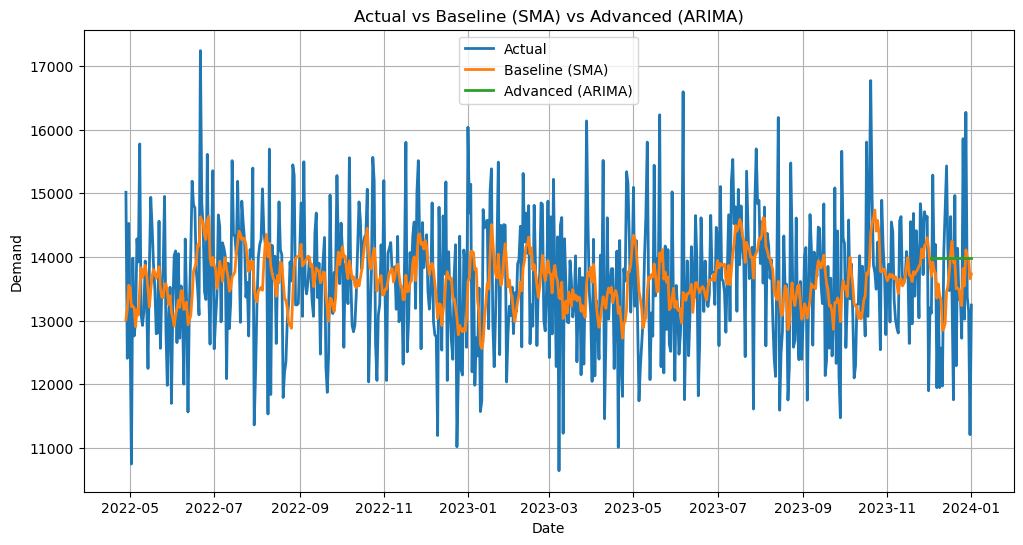

In [11]:
plt.figure(figsize=(12,6))

plt.plot(
    baseline_test["Date"],
    baseline_test["Units Sold"],
    label="Actual",
    linewidth=2
)

plt.plot(
    baseline_test["Date"],
    baseline_test["SMA_7"],
    label="Baseline (SMA)",
    linewidth=2
)

plt.plot(
    test_df["Date"],
    test_df["ARIMA_Prediction"],
    label="Advanced (ARIMA)",
    linewidth=2
)

plt.title("Actual vs Baseline (SMA) vs Advanced (ARIMA)")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()
plt.grid(True)

plt.show()

### Key Findings

- Both Baseline (SMA) and Advanced (ARIMA) forecasting models were evaluated.
- RMSE and MAPE were calculated for both models.
- Lower RMSE indicates higher prediction accuracy.
- Lower MAPE indicates lower percentage forecasting error.
- The comparison clearly shows the forecasting performance of both models on the testing dataset.

# Conclusion

The forecasting model was evaluated using chronological train-test splitting and standard forecasting evaluation metrics.

RMSE and MAPE were calculated to assess prediction accuracy, and the comparison between actual and predicted values demonstrated the effectiveness of the forecasting model. Overall, the advanced forecasting approach provides dependable demand forecasts and can support better inventory planning and decision-making.

In [12]:
# Export Forecast Results

forecast_results.to_excel(
    "forecast_test_predictions.xlsx",
    index=False
)

performance_summary.to_excel(
    "model_evaluation_summary.xlsx",
    index=False
)

print("Evaluation reports exported successfully.")

Evaluation reports exported successfully.
